# Resolution Analysis:
Floating point math can produce rounding errors that affect geometric computations. In addition, hand-drawn contours may have coordinates that are not perfectly aligned, leading to unexpected results when determining spatial relationships. 


## Setup

### Imports

#### Type imports

In [1]:
from typing import List, Tuple, Union, Iterable


In [2]:
from math import radians, cos, sin
import logging


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shapely
from shapely.plotting import plot_polygon, plot_line


In [4]:
from types_and_classes import DEFAULT_TRANSVERSE_TOLERANCE
from types_and_classes import SLICE_INDEX_PRECISION
from types_and_classes import Coordinate, ContourPointsType

from types_and_classes import InvalidContour

from utilities import round_value, points_to_polygon
from debug_tools import plot_ab, make_vertical_cylinder, make_sphere, circle_points
from contours import ContourPoints

from relations import DE9IM, DE27IM

In [5]:
%matplotlib inline

In [6]:
# Configure logging if not already configured
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


## Demo of floating point rounding effect on relation analysis

We create a cropped circle and a full circle. The cropped circle is derived from a smaller circle, offset to the right and cropped at the boundary with the full circle. 

The expected relationship of the cropped circle to the full circle is "Partition" `(T*T*T*F**)`


<link rel="stylesheet" href="../../relations.css">
<table><tr><td>
<table  style="border: none;">
<tr class="l"  style="border: none;">
<th style="border: none;">Partition</th>
<th width=100 rowspan=2 style="border: none;">
<img src="../../Images/Relationships/partitions simple.png" alt="Partition">
</th></tr>
<tr style="border: none;"><td class="d" style="border: none;">
The boundaries of <span class="a">a</span> and <span class="b">b</span> have more than one point in common.
No points of <span class="b">b</span> are exterior to <span class="a">a</span>, and some points in <span class="a">a</span> are exterior to <span class="b">b</span>.
</td></tr></table>
</td><td>
<table class="f">
<tr><th>Matrix</th>
<td><table class="matrix">        
    <tr><td>T</td><td>*</td><td>T</td></tr>
    <tr><td>F</td><td>T</td><td>*</td></tr>
    <tr><td>*</td><td>*</td><td>*</td></tr>
    </table>
    </td>
</tr>
</tr><tr class="bin">
<th>Mask</th><td><span>101110000</span></td></tr>
<tr class="bin">
<th>Value</th><td><span>101010000</span></td></tr>
</table>
</tr></tr></table>

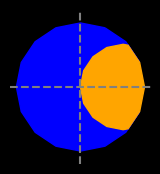

In [7]:
full_circle = shapely.Polygon(circle_points(3,tolerance=0.0))
circle4_offset = shapely.Polygon(circle_points(2, offset_x=2, tolerance=0.0))
cropped_circle = shapely.intersection(full_circle, circle4_offset)
ax = plot_ab(full_circle, cropped_circle)

In [8]:
r = DE9IM(full_circle, cropped_circle)
print(r)
print(full_circle.relate(cropped_circle))
r = DE27IM(full_circle, cropped_circle)
print(r.identify_relation())
dif = cropped_circle - full_circle
coords = shapely.get_coordinates(dif).tolist()
print(f'The difference in area is {dif.area}')
print(f'The difference coordinates are: {coords}')

#print('\nThe reversed relationship is:')
#rev_r = DE9IM(cropped_circle, full_circle)
#print(rev_r)
#print(cropped_circle.relate(full_circle))

|111|
|011|
|001|
212F11FF2
Relationship: Partition
The difference in area is 0.0
The difference coordinates are: []


The "Overlaps" relationship (`'212111212'`) indicates that the two polygons share some interior area, but neither is completely within the other.  
In other words, both polygons have parts that are exterior to the other.
However, the difference between `cropped_circle` and `full_circle` is an empty polygon, meaning that `cropped_circle` is entirely within `full_circle`.
The transposed relation produces the same result, which is also incorrect.

#### If tolerance is set to 0.1, the result is correct

In [9]:
full_circle_rounded = shapely.Polygon(circle_points(3, tolerance=0.1))
circle4_offset_rounded = shapely.Polygon(circle_points(2, offset_x=2,
                                                       tolerance=0.1))
cropped_circle_rounded = shapely.intersection(full_circle_rounded,
                                              circle4_offset_rounded)

print(full_circle_rounded.relate(cropped_circle_rounded))
r = DE27IM(full_circle_rounded, cropped_circle_rounded)
print(r)
print(r.identify_relation())


212F11FF2
|111| |111| |111|
|011| |011| |011|
|001| |001| |001|

Relationship: Partition


## Rounding Functions

There are several ways to perform the necessary rounding to ensure that contours are compared at the same resolution.
Two of the simplest approaches are:
1. Rounding the polygon coordinates
2. Snapping polygons to a pre-defined grid.


### Rounding Polygon Coordinates
One way is to round the coordinates of contour points to a specified resolution before performing geometric operations.  However, this can result in invalid geometries if not done carefully.  Invalid geometries can be fixed using the shapely.make_valid() function, and then select the largest resulting polygon.


#### `round_contour_points`
- Rounds the coordinates of contour points to a specified tolerance.

In [10]:
def round_contour_points(contour_points: ContourPointsType,
                         resolution=DEFAULT_TRANSVERSE_TOLERANCE) -> ContourPointsType:
    '''Round contour points to the specified resolution.

    Rounds the x and y coordinates of all contour points to the nearest
    resolution increment. Z coordinates are left unchanged as they typically
    represent slice positions that should remain precise.

    Args:
        contour_points (ContourPointsType): A list of length 2 or three tuples
            of float containing the (x, y) or (x, y, z) coordinates that define
            a contour.
        resolution (float, optional): The resolution increment to round to in
            cm. Defaults to DEFAULT_TRANSVERSE_TOLERANCE.

    Returns:
        ContourPointsType: A new list of contour points with x and y
            coordinates rounded to the specified resolution.

    '''
    if not contour_points:
        logger.debug("No contour points to round")
        return []
    if isinstance(contour_points, shapely.Polygon):
        contour_points = shapely.get_coordinates(contour_points).tolist()

    if resolution <= 0:
        raise ValueError("Resolution must be a positive number")
    # Determine the number of decimal places for rounding based on resolution
    decimal_places = -int(np.log10(resolution)) + 1
    logger.debug(f"Rounding to resolution: {resolution} cm, decimal places: {decimal_places}")

    # convert contour_points to numpy array for easier manipulation
    points = np.array(contour_points)
    original_points = points.copy()

    # convert x and y coordinates to multiple of resolution
    points[:, 0] = (points[:, 0] // resolution) * resolution
    points[:, 1] = (points[:, 1] // resolution) * resolution
    # Round x and y coordinates to avoid floating point issues
    points[:, 0] = np.round(points[:, 0], decimals=decimal_places)
    points[:, 1] = np.round(points[:, 1], decimals=decimal_places)

    # Z coordinates ([:, 2]) are left unchanged

    # convert back to list of tuples
    rounded_points = points.tolist()

    # Difference between the original and rounded points
    differences = np.abs(np.array(rounded_points) - original_points)
    logger.debug(f"Max difference (x, y): {np.max(differences[:, :2], axis=0)}")
    logger.debug(f"Average difference (x, y): {np.mean(differences[:, :2], axis=0)}")

    return rounded_points

##### Quick demo of `round_contour_points`


Original points: (0.12345, 1.23456), (2.34567, -0.98765), (3.14159, 2.71828)
round_contour_points returned: [[0.0, 1.2], [2.2, -1.0], [3.0, 2.6]]
Rounded points (resolution=0.2): (0.0, 1.2), (2.2, -1.0), (3.0, 2.6)


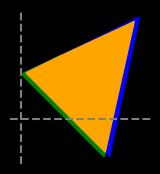

In [11]:
sample_contour = [(0.12345, 1.23456), (2.34567, -0.98765), (3.14159, 2.71828)]
example_resolution = 0.2  # Example resolution for rounding
print(f'Original points: {", ".join(str(p) for p in sample_contour)}')

ret = round_contour_points(sample_contour, resolution=example_resolution)
print(f'round_contour_points returned: {ret}')

# Compute and show rounded result (round_contour_points does not return the rounded points)
arr = np.array(sample_contour)
arr[:, 0] = (arr[:, 0] // example_resolution) * example_resolution
arr[:, 1] = (arr[:, 1] // example_resolution) * example_resolution
decimal_places = -int(np.log10(example_resolution)) + 1
# Round x and y coordinates to avoid floating point issues
arr[:, 0] = np.round(arr[:, 0], decimals=decimal_places)
arr[:, 1] = np.round(arr[:, 1], decimals=decimal_places)

rounded_points = [tuple(float(x) for x in row) for row in arr]

print(f'Rounded points (resolution={example_resolution}): {", ".join(str(p) for p in rounded_points)}')

# Visual comparison between original and rounded polygons
poly_orig = shapely.Polygon(sample_contour)
poly_rounded = shapely.Polygon(rounded_points)
ax = plot_ab(poly_orig, poly_rounded)

#### `make_coordinates_valid`
- Rounding the coordinates of of a polygon can result in an invalid polygon 
when there are closely spaced "noisy" coordinates.  
- This can be fixed using the shapely.make_valid() function, and then select the largest resulting polygon.


In [12]:
def make_coordinates_valid(contour: ContourPointsType)->ContourPointsType:
    '''Fix invalid geometries resulting from rounding coordinates.
    using shapely.make_valid() and return the largest polygon.

    This function applies shapely.make_valid() to the clean up small loops,
    crosses, or duplicated points in the rounded contour points. If the
    result contains multiple polygonal parts (MultiPolygon or GeometryCollection),
    the largest polygon by area is selected and returned. If no polygonal part
    is found, the function returns the geometry produced by make_valid().

    Args:
        geom: A shapely geometry that may be invalid.

    Returns:
        The largest shapely Polygon found after making the geometry valid, or
        the make_valid() result if only one polygonal part exists.
    '''
    if not contour:
        logger.debug("No contour points to round")
        return []
    # Handle both ContourPointsType and shapely.Polygon inputs
    if isinstance(contour, shapely.Polygon):
        original_polygon = contour
    else:
        original_polygon = shapely.Polygon(contour)

    valid_polygon = shapely.make_valid(original_polygon)

    # If already a single polygon, return it
    if isinstance(valid_polygon, shapely.Polygon):
        logger.debug(f'Returned geometry is a Polygon with area '
                     f'{valid_polygon.area}')
        return valid_polygon

    # Collect polygons parts from the made-valid geometry
    if isinstance(valid_polygon, (shapely.MultiPolygon,
                                  shapely.GeometryCollection)):
        polygons = []
        for polygon in valid_polygon.geoms:
            # Skip non-polygon geometries
            if isinstance(polygon, shapely.Polygon):
                polygons.append([polygon, polygon.area])
            # Split up MultiPolygon into individual polygons
            elif isinstance(polygon, shapely.MultiPolygon):
                for sub_polygon in polygon.geoms:
                    polygons.append([sub_polygon, sub_polygon.area])
        if polygons:
            polygons.sort(key=lambda p: p[1], reverse=True)
            largest = polygons[0][0]
            logger.debug(f'Found {len(polygons)} polygon parts, returning '
                         f'largest area {polygons[0][1]}')

    # if no polygon parts found, contour_points do not form a valid polygon
    else:
        raise InvalidContour('Coordinates do not form a valid polygon.')

    return largest

##### Quick demo of `make_coordinates_valid`

Original points: (0.12345, 1.23456), (2.34567, -0.98765), (2.44567, -0.98765), (2.2567, -0.99765), (2.45567, -0.98765), (2.38, -0.95), (2.39, -0.9432), (3.14159, 2.71828)
Rounded points: [0.0, 1.2], [2.2, -1.0], [2.4, -1.0], [2.2, -1.0], [2.4, -1.0], [2.2, -1.0], [2.2, -1.0], [3.0, 2.6]
Original polygon is valid: True, area: 5.068548
Rounded polygon is valid: False, area: 4.840000
Corrected polygon is valid: True, area: 4.840000


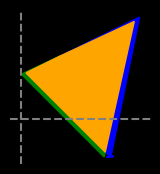

In [13]:
# Simple example containing a small loop
sample_contour = [(0.12345, 1.23456), (2.34567, -0.98765), (2.44567, -0.98765),
                  (2.2567, -0.99765), (2.45567, -0.98765), (2.38000, -0.95000),
                  (2.3900, -0.9432),(3.14159, 2.71828)]
example_resolution = 0.2  # Example resolution for rounding

rounded = round_contour_points(sample_contour, resolution=example_resolution)
print(f'Original points: {", ".join(str(p) for p in sample_contour)}')
print(f'Rounded points: {", ".join(str(p) for p in rounded)}')
original_polygon = shapely.Polygon(sample_contour)
print(f'Original polygon is valid: {original_polygon.is_valid}, '
      f'area: {original_polygon.area:.6f}')
shapely_poly_rounded = shapely.Polygon(rounded)
print(f'Rounded polygon is valid: {shapely_poly_rounded.is_valid}, '
      f'area: {shapely_poly_rounded.area:.6f}')

# Create polygons from the rounded coordinates and apply make_coordinates_valid
poly_rounded = shapely.Polygon(rounded)
valid_polygon = make_coordinates_valid(rounded)

print(f'Corrected polygon is valid: {valid_polygon.is_valid}, '
      f'area: {valid_polygon.area:.6f}')

# Visual comparison between the rounded polygon and the made-valid geometry
ax = plot_ab(original_polygon, valid_polygon)

#### Applying these functions to the demo contours

|111|
|001|
|001|
212F01FF2
Relationship: Contains


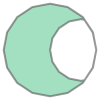

In [14]:
resolution=0.01
num_points = 16
full_circle_coordinates = circle_points(3, tolerance=0.0,
                                        num_points=num_points)
full_circle_rounded = round_contour_points(full_circle_coordinates,
                                           resolution=resolution)
full_circle = make_coordinates_valid(full_circle_rounded)

circle4_offset = shapely.Polygon(circle_points(2, offset_x=2, tolerance=0.0,
                                               num_points=num_points))
cropped_circle = shapely.intersection(full_circle, circle4_offset)
cropped_circle_coordinates = shapely.get_coordinates(cropped_circle).tolist()
cropped_circle_rounded = round_contour_points(cropped_circle_coordinates,
                                              resolution=resolution)
cropped_circle = make_coordinates_valid(cropped_circle_rounded)

r = DE9IM(full_circle, cropped_circle)
print(r)
print(full_circle.relate(cropped_circle))
r = DE27IM(full_circle, cropped_circle)
print(r.identify_relation())

rev_dif = full_circle - cropped_circle
rev_dif

The "Contains" relationship (`'212F01FF2'`) indicates that the border of the `cropped_circle` no longer intersects with the `full_circle`.
This is the result of either too much rounding or not enough points in the circles.


#### Retry with less rounding

|111|
|001|
|001|
212F01FF2
Relationship: Contains


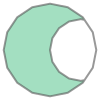

In [15]:
resolution = 0.01 / 10
num_points = 16
full_circle_coordinates = circle_points(3, tolerance=0.0,
                                        num_points=num_points)
full_circle_rounded = round_contour_points(full_circle_coordinates,
                                           resolution=resolution)
full_circle = make_coordinates_valid(full_circle_rounded)

circle4_offset = shapely.Polygon(circle_points(2, offset_x=2, tolerance=0.0,
                                               num_points=num_points))
cropped_circle = shapely.intersection(full_circle, circle4_offset)
cropped_circle_coordinates = shapely.get_coordinates(cropped_circle).tolist()
cropped_circle_rounded = round_contour_points(cropped_circle_coordinates,
                                              resolution=resolution)
cropped_circle = make_coordinates_valid(cropped_circle_rounded)

r = DE9IM(full_circle, cropped_circle)
print(r)
print(full_circle.relate(cropped_circle))
r = DE27IM(full_circle, cropped_circle)
print(r.identify_relation())

rev_dif = full_circle - cropped_circle
rev_dif

A factor of 10 less rounding still produces the incorrect "Contains" relationship.

##### Repeating the process with a higher number of points in the circles (originally 16)

|111|
|111|
|111|
212111212
Relationship: Overlaps


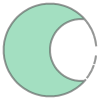

In [16]:
resolution = 0.01
num_points = 160
full_circle_coordinates = circle_points(3, tolerance=0.0,
                                        num_points=num_points)
full_circle_rounded = round_contour_points(full_circle_coordinates,
                                           resolution=resolution)
full_circle = make_coordinates_valid(full_circle_rounded)

circle4_offset = shapely.Polygon(circle_points(2, offset_x=2, tolerance=0.0,
                                               num_points=num_points))
cropped_circle = shapely.intersection(full_circle, circle4_offset)
cropped_circle_coordinates = shapely.get_coordinates(cropped_circle).tolist()
cropped_circle_rounded = round_contour_points(cropped_circle_coordinates,
                                              resolution=resolution)
cropped_circle = make_coordinates_valid(cropped_circle_rounded)

r = DE9IM(full_circle, cropped_circle)
print(r)
print(full_circle.relate(cropped_circle))
r = DE27IM(full_circle, cropped_circle)
print(r.identify_relation())

rev_dif = full_circle - cropped_circle
rev_dif

The result is some points are rounded too low and some too high, causing the 
borders to cross each other, and giving an incorrect relation.

##### Try adding filler points to the circles before rounding

|111|
|111|
|111|
212111212
Relationship: Overlaps


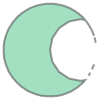

In [17]:
resolution = 0.01
num_points = 16
max_length = .5
full_circle_coordinates = circle_points(3, tolerance=0.0,
                                        num_points=num_points)
full_circle_filled = shapely.segmentize(full_circle,
                                        max_segment_length=max_length)
full_circle_rounded = round_contour_points(full_circle_filled,
                                           resolution=resolution)
full_circle = make_coordinates_valid(full_circle_rounded)

circle4_offset = shapely.Polygon(circle_points(2, offset_x=2, tolerance=0.0,
                                               num_points=num_points))
cropped_circle = shapely.intersection(full_circle, circle4_offset)
cropped_circle_coordinates = shapely.get_coordinates(cropped_circle).tolist()
cropped_circle_filled = shapely.segmentize(cropped_circle,
                                           max_segment_length=max_length)
cropped_circle_rounded = round_contour_points(cropped_circle_filled,
                                              resolution=resolution)
cropped_circle = make_coordinates_valid(cropped_circle_rounded)

r = DE9IM(full_circle, cropped_circle)
print(r)
print(full_circle.relate(cropped_circle))
r = DE27IM(full_circle, cropped_circle)
print(r.identify_relation())

rev_dif = full_circle - cropped_circle
rev_dif

This didn't help either.

Another approach is to use the `shapely.snap()` function to snap the polygons 
to each other. This can help ensure that points on the polygons that are meant 
to be coincident are treated as such.

|111|
|011|
|001|
212F11FF2
Relationship: Partition


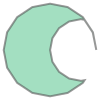

In [18]:
resolution=0.01
num_points = 16
full_circle_coordinates = circle_points(3, tolerance=0.0,
                                        num_points=num_points)
full_circle_rounded = round_contour_points(full_circle_coordinates,
                                           resolution=resolution)
full_circle = make_coordinates_valid(full_circle_rounded)

circle4_offset = shapely.Polygon(circle_points(2, offset_x=2, tolerance=0.0,
                                               num_points=num_points))
cropped_circle = shapely.intersection(full_circle, circle4_offset)
cropped_circle_coordinates = shapely.get_coordinates(cropped_circle).tolist()
cropped_circle_rounded = round_contour_points(cropped_circle_coordinates,
                                              resolution=resolution)
cropped_circle = make_coordinates_valid(cropped_circle_rounded)

snapped_full_circle = shapely.snap(full_circle, cropped_circle,
                                   tolerance=resolution)
snapped_cropped_circle = shapely.snap(cropped_circle, full_circle,
                                      tolerance=resolution)
r = DE9IM(snapped_full_circle, snapped_cropped_circle)
print(r)
print(snapped_full_circle.relate(snapped_cropped_circle))
r = DE27IM(snapped_full_circle, snapped_cropped_circle)
print(r.identify_relation())

rev_dif = snapped_full_circle - snapped_cropped_circle
rev_dif

This works, but changing the number of points only slightly, causes the 
relationship to fail.

|111|
|111|
|111|
212111212
Relationship: Overlaps


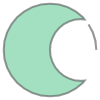

In [19]:
resolution=0.01
num_points = 32
full_circle_coordinates = circle_points(3, tolerance=0.0,
                                        num_points=num_points)
full_circle_rounded = round_contour_points(full_circle_coordinates,
                                           resolution=resolution)
full_circle = make_coordinates_valid(full_circle_rounded)

circle4_offset = shapely.Polygon(circle_points(2, offset_x=2, tolerance=0.0,
                                               num_points=num_points))
cropped_circle = shapely.intersection(full_circle, circle4_offset)
cropped_circle_coordinates = shapely.get_coordinates(cropped_circle).tolist()
cropped_circle_rounded = round_contour_points(cropped_circle_coordinates,
                                              resolution=resolution)
cropped_circle = make_coordinates_valid(cropped_circle_rounded)

snapped_full_circle = shapely.snap(full_circle, cropped_circle,
                                   tolerance=resolution)
snapped_cropped_circle = shapely.snap(cropped_circle, full_circle,
                                      tolerance=resolution)
r = DE9IM(snapped_full_circle, snapped_cropped_circle)
print(r)
print(snapped_full_circle.relate(snapped_cropped_circle))
r = DE27IM(snapped_full_circle, snapped_cropped_circle)
print(r.identify_relation())

rev_dif = snapped_full_circle - snapped_cropped_circle
rev_dif

### Snapping Polygons to a Pre-defined Grid
Another approach is to use the `shapely.snap()` function to snap polygons that are within a certain tolerance to each other. This can help ensure that polygons that are meant to be coincident are treated as such, reducing the likelihood of errors in geometric computations. 

The snap should employ a grid of points at the desired resolution that extend over the entire range of the polygons. This will ensure that all points are aligned to the grid, allowing all contours to be compared at the same resolution.  The snap tolerance should be half the grid spacing to ensure that points are snapped to the nearest grid point.


#### `make_grid_multipoint`
- Generate a grid of points within the specified bounds and tolerance.
- This is used to create a multi-point representation of the area, which can be 
used to snap polygons to the grid.


In [20]:
def make_grid_multipoint(bounds: Tuple[Tuple[float, float], Tuple[float, float]],
                         tolerance: float = DEFAULT_TRANSVERSE_TOLERANCE) -> 'shapely.geometry.MultiPoint':
    '''Create a shapely.MultiPoint covering the supplied bounds using a grid.

    The grid spacing is controlled by tolerance. The bounds argument should be
    of the form ((min_x, max_x), (min_y, max_y)). Coordinates are snapped to
    the grid to avoid floating point artifacts.

    Args:
        bounds: Tuple of X and Y bounds as ((min_x, max_x), (min_y, max_y)).
        tolerance: Grid spacing in the same units as bounds. Defaults to
            DEFAULT_TRANSVERSE_TOLERANCE.

    Returns:
        A shapely.MultiPoint containing the grid points that span the bounds.

    Raises:
        InvalidContour: If bounds are malformed or min is greater than max.
        ValueError: If tolerance is not a positive number.
    '''
    if bounds is None or len(bounds) != 2:
        raise InvalidContour('Bounds must be a tuple of ((min_x, max_x), (min_y, max_y)).')

    (min_x, max_x), (min_y, max_y) = bounds

    if min_x > max_x or min_y > max_y:
        raise InvalidContour(f'Bounds invalid: X ({min_x}, {max_x}) or Y ({min_y}, {max_y}) '
                             f'has min greater than max.')

    if tolerance <= 0:
        raise ValueError('Tolerance must be a positive number')

    # Use arange with a small extension to ensure the max bound is included,
    # then snap values to the grid to avoid floating point drift.
    xs = np.arange(min_x, max_x + tolerance * 0.5, tolerance)
    ys = np.arange(min_y, max_y + tolerance * 0.5, tolerance)

    # Snap to grid by rounding to multiples of tolerance
    xs = (np.round(xs / tolerance) * tolerance).astype(float)
    ys = (np.round(ys / tolerance) * tolerance).astype(float)

    # Remove duplicates that can occur due to rounding
    xs = np.unique(xs)
    ys = np.unique(ys)

    if xs.size == 0 or ys.size == 0:
        logger.debug('Generated empty grid for bounds: '
                     f'X:({min_x},{max_x}) Y:({min_y},{max_y})')
        return shapely.MultiPoint()

    coords = [(float(x), float(y)) for x in xs for y in ys]

    logger.debug(f'Generated grid with {len(coords)} points spanning '
                 f'X:({xs[0]},{xs[-1]}) Y:({ys[0]},{ys[-1]}) at tolerance {tolerance}')

    return shapely.MultiPoint(coords)

##### Quick demo of `make_grid_multipoint`

Bounds: ((0.0, 1.0), (0.0, 1.0)), tolerance: 0.2
Generated points: 36
First points: (0.0, 0.0), (0.0, 0.2), (0.0, 0.4), (0.0, 0.6000000000000001), (0.0, 0.8)


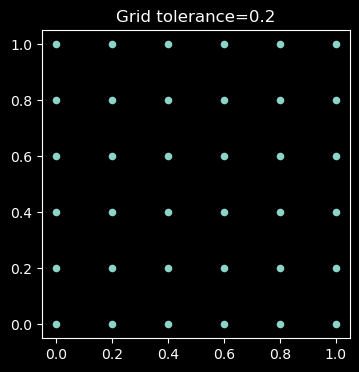

In [21]:
# Simple examples of make_grid_multipoint
examples = [
#    {'bounds': ((0.0, 1.0), (0.0, 1.0)), 'tolerance': 0.5},
#    {'bounds': ((-1.0, 1.0), (0.0, 0.5)), 'tolerance': 0.5},
    {'bounds': ((0.0, 1.0), (0.0, 1.0)), 'tolerance': 0.2},
]

for ex in examples:
    bounds = ex['bounds']
    tolerance = ex['tolerance']
    mp = make_grid_multipoint(bounds, tolerance=tolerance)
    pts = [(float(p.x), float(p.y)) for p in mp.geoms]

    print(f'Bounds: {bounds}, tolerance: {tolerance}')
    print(f'Generated points: {len(pts)}')
    print('First points: ' + ', '.join(str(p) for p in pts[:5]))

    fig = plt.figure(figsize=(4, 4))
    ax = fig.gca()
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    ax.scatter(xs, ys, s=20)
    ax.set_title(f'Grid tolerance={tolerance}')
    ax.set_aspect('equal')
    plt.show()

#### `largest_xy_bounds`
- Return the largest X and Y bounds for a list of contours.
- This is used to find the bounding box that contains all contours, rounded and expanded by a specified tolerance.


In [22]:
def largest_xy_bounds(contour_points: Union[List[ContourPoints], List[List[ContourPointsType]]],
                      tolerance: float = DEFAULT_TRANSVERSE_TOLERANCE
                      ) -> Tuple[Tuple[float, float], Tuple[float, float]]:
    '''Return the largest X and Y bounds for contours, polygons, or a mix of both.

    The function accepts either:
    - A list of contours (each an iterable of (x, y) coordinates)
    - A list of ContourPoints (dictionaries with 'Points' key)
    - A single polygon or list of polygons (shapely geometries)
    - A mix of the above types

    Coordinates are rounded to the specified tolerance before being returned.

    Args:
        contour_points: A ContourPointsType, list of ContourPointsType,
            shapely geometry, or list of mixed types.
        tolerance: Either a fractional transverse resolution (e.g. 0.01) or an
            integer number of decimal places. Defaults to TRANSVERSE_PRECISION.

    Returns:
        A tuple ((min_x, max_x), (min_y, max_y)) with values rounded to the
        requested tolerance.

    Raises:
        InvalidContour: If no valid points are provided or points lack x/y.
    '''
    if contour_points is None:
        raise InvalidContour('No contour points provided')

    if not isinstance(contour_points, Iterable):
        if isinstance(contour_points, shapely.Geometry):
            contour_points = shapely.get_coordinates(contour_points).tolist()
        else:
            raise InvalidContour('Contour points must be an iterable of '
                                 'ContourPoints, a sequence of coordinates, or a '
                                 'single coordinate tuple.')

    if isinstance(contour_points[0], ContourPoints):
            points = [slice['Points'] for slice in contour_points]
    elif isinstance(contour_points[0], shapely.Geometry):
        points = []
        for geom in contour_points:
            coords = shapely.get_coordinates(geom).tolist()
            points.extend(coords)
    else:
        points = contour_points
    points_arr = np.asarray(points, dtype=float)
    if points_arr.size == 0:
        raise InvalidContour('No coordinate points found in contour_points')
    shp = points_arr.shape

    # Verify that the last dimension represents 2D or 3D coordinates.
    if shp[-1] not in (2, 3):
        raise InvalidContour(f'Coordinate tuples must have length 2 or 3, '
                             f'found {shp[-1]}')
    if len(shp) > 1:
        # If multiple coordinates are provided, flatten array into 2 dimensions,
        # Where each row is a point with (x, y) or (x, y, z).
        arr = points_arr.reshape(np.prod(shp[:-1]), shp[-1])
    else:
        arr = points_arr.reshape(1, shp[-1])

    bounds = [(float(np.min(arr[:, 0])), float(np.max(arr[:, 0]))),
              (float(np.min(arr[:, 1])), float(np.max(arr[:, 1])))]

    # Expand bounds by one tolerance value to ensure all points are included
    bounds_expanded = [
        (bounds[0][0] - tolerance, bounds[0][1] + tolerance),
        (bounds[1][0] - tolerance, bounds[1][1] + tolerance)
        ]
    # Round bounds to the specified tolerance
    rounded_bounds = round_contour_points(bounds_expanded, tolerance)

    logger.debug(f'Computed bounds '
                 f'X: ({rounded_bounds[0][0]}, {rounded_bounds[0][1]}), '
                 f'Y: ({rounded_bounds[1][0]}, {rounded_bounds[1][1]})')

    return rounded_bounds

##### Quick demo of `largest_xy_bounds`

In [23]:
def nested_spheres_example():
    slice_spacing = 1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=16, length=20, offset_z=0,
                                  spacing=slice_spacing)
    sphere12 = make_sphere(roi_num=1, radius=6, spacing=slice_spacing)
    hole10 = make_sphere(roi_num=1, radius=5, spacing=slice_spacing)
    sphere8 = make_sphere(roi_num=1, radius=4, spacing=slice_spacing)
    sphere6 = make_sphere(roi_num=2, radius=3, spacing=slice_spacing)

    # combine the contours
    slice_data = body + sphere12 + hole10 + sphere8 + sphere6
    return slice_data


In [24]:
slice_data = nested_spheres_example()
largest_xy_bounds(slice_data, tolerance=0.1)

[[-16.2, 16.1], [-16.2, 16.1]]

In [25]:
sample_contour = [(0.12345, 1.23456), (2.34567, -0.98765), (2.44567, -0.98765),
                  (2.2567, -0.99765), (2.45567, -0.98765), (2.38000, -0.95000),
                  (2.3900, -0.9432),(3.14159, 2.71828)]
largest_xy_bounds(sample_contour, tolerance=0.1)

[[0.0, 3.2], [-1.1, 2.8]]

In [26]:
single_point = (1.23456, 2.34567)
largest_xy_bounds(single_point, tolerance=0.1)

[[1.1, 1.3], [2.2, 2.4]]

#### Applying these functions to the demo contours

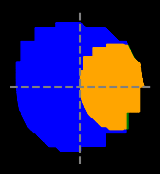

In [27]:
resolution = 0.01
full_circle = shapely.Polygon(circle_points(3, tolerance=resolution))
circle4_offset = shapely.Polygon(circle_points(2, offset_x=2, tolerance=resolution))
cropped_circle = shapely.intersection(full_circle, circle4_offset)
bounds = largest_xy_bounds([cropped_circle, full_circle], tolerance=resolution)
grid = make_grid_multipoint(bounds, tolerance=resolution)

snapped_full_circle = shapely.snap(full_circle, grid,tolerance=resolution)
snapped_cropped_circle = shapely.snap(cropped_circle, grid,tolerance=resolution)
ax = plot_ab(snapped_full_circle, snapped_cropped_circle)

- Snap is not behaving as expected.  Drop it.


Another tool that can be used is the shapely.simplify() function, which reduces the number of points in a geometry while preserving its overall shape. This can help reduce the complexity of geometric computations and improve performance.  The tolerance for simplification should be set to the desired resolution.


# Done to Here
**Next Attempt:**
- Try creating a rind for each polygon with resolution thickness checking the relation between the rinds to identify boundary relations.
    1. Create rinds at the same time that hulls are created.
    2. For the smaller polygon, subtract the rind from the polygon berfor getting the relationship to avoid false overlaps.
    2. Use DE9IM to check the relation between the rinds.
    3. Transform the rind DE9IM matrix to get the boundary relations.
    4. Merge the rind relations with the interior relations to get the final relations.

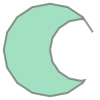

In [28]:
resolution=0.01
num_points = 16
full_circle_coordinates = circle_points(3, tolerance=0.0,
                                        num_points=num_points)
full_circle_rounded = round_contour_points(full_circle_coordinates,
                                           resolution=resolution)
full_circle = make_coordinates_valid(full_circle_rounded)

circle4_offset = shapely.Polygon(circle_points(2, offset_x=2, tolerance=0.0,
                                               num_points=num_points))
cropped_circle = shapely.intersection(full_circle, circle4_offset)
full_circle - cropped_circle


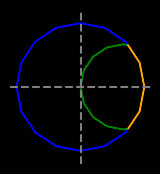

In [29]:
full_circle_boundary = full_circle.exterior.buffer(resolution)
cropped_circle_boundary = cropped_circle.exterior.buffer(resolution)
expanded_full_circle = shapely.union_all([full_circle, full_circle_boundary])
shrunk_cropped_circle = cropped_circle - cropped_circle_boundary

ax = plot_ab(full_circle_boundary, cropped_circle_boundary)

In [30]:
r_a = DE9IM(full_circle_boundary, shrunk_cropped_circle)
r_a = r_a.boundary_adjustment('a')
print('Boundary of A')
print(r_a)

print('\nBoundary of B')
r_b = DE9IM(expanded_full_circle, cropped_circle_boundary)
r_b = r_b.boundary_adjustment('b')
print(r_b)

print('\nCombined Boundaries')
r_c = DE9IM(full_circle_boundary, cropped_circle_boundary)
r_c = r_c.boundary_adjustment('a')
r_c = r_c.boundary_adjustment('b')
print(r_c)

print('\nPolygon Relation')
r = DE9IM(expanded_full_circle, shrunk_cropped_circle)
print(r)

Boundary of A
|000|
|011|
|111|

Boundary of B
|011|
|011|
|001|

Combined Boundaries
|000|
|011|
|011|

Polygon Relation
|111|
|001|
|001|


In [31]:

print('\nCombined Relations')
r_f = r.merge([r, r_a, r_b,r_c])
print(r_f)

print('\nCombined Relations as DE27IM')
r_f27_str = r_f.relation_str + '0'*18

r_f = DE27IM(r_f27_str)
print(r_f.identify_relation())


Combined Relations
|111|
|011|
|111|

Combined Relations as DE27IM
Relationship: Unknown


- Boundary of A is the problem
- Here we don't care about the polygon vs boundary relations
- Do we care about it at the SUP and INF ends?

In [32]:
print('\nCombined Relations')
r_fc = r.merge([r,r_c])
print(r_fc)
r27_str = r_fc.relation_str + '0'*18
r27_str
r27 = DE27IM(relation_str=r27_str)
r27
print(r27.identify_relation())


Combined Relations
|111|
|011|
|011|
Relationship: Partition



**Partitions**

     T * T
     * T *
     F * *

     T * T
     * T *
     F * *

     T * T
     * * *
     F * *

    `Region Test  Exterior Test  Hull Test`
    `T*T*T*F**    T*T*T*F**      T*T***F**`

***A*** contains ***B*** and part of the *boundary* of ***B*** touches part of the *boundary* of ***A***.

|111|<br>
|011|<br>
|001|<br>
212F11FF2<br>
Relationship: Partition


**RelationshipTest(RelationshipType.PARTITION,**

    Region Test  Exterior Test  Hull Test
    T*T*T*F**    T*T*T*F**      T*T***F**
    101010100    101010100      101000100
    101010000    101010000      101000000

**RelationshipTest(RelationshipType.PARTITION,**

    Region Test  Exterior Test  Hull Test
    T*T*T*F**    T*T*T*F**      T*T***F**
    101010100    000000000      000000000
    101010000    000000000      000000000